## Notebook 3 for clustering processing

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib.cm as cm
import pandas as pd
import seaborn as sns
import os

from tqdm import tqdm

import hdbscan

from scipy.spatial.distance import cdist

from sklearn.preprocessing import StandardScaler

from sklearn.metrics import r2_score, silhouette_score, accuracy_score, confusion_matrix#, calinski_harabasz_score, davies_bouldin_score

from sklearn.decomposition import PCA

from sklearn.manifold import TSNE

from sklearn.cluster import KMeans, MiniBatchKMeans
from sklearn.cluster import DBSCAN
from sklearn.cluster import SpectralClustering
from sklearn.cluster import AgglomerativeClustering
from sklearn.ensemble import RandomForestClassifier
from sklearn.mixture import GaussianMixture

import plotly.express as px
import plotly.graph_objects as go

In [2]:
# import the merged data file
merged_df = pd.read_csv('fusion_results_merged.csv.gzip', compression='gzip', sep=',', header=0, dtype={'# sample': str, 'Depth': str})
merged_df.head()

,Mg,Al,Si,K,Ca,Ti,Mn,Fe,Rb,Sr,...,Ce,Sum,Filename,Core,# sample,Depth,Conductivity,# Non-soluble dust,d18O,dD
0,0.0,0.0000,0.0,0.0,0.0,0.0,0.0,4364.6397,0.0,0.0,...,0.0,4364.6397,1137 2410,1137,2410,100.00883945750563,0.076415,177.153846,-56.665723,-439.623557
1,0.0,3359.1233,0.0,0.0,0.0,0.0,0.0,0.0000,0.0,0.0,...,0.0,3359.1233,1137 2410,1137,2410,100.00883945750563,0.076415,177.153846,-56.665723,-439.623557
2,0.0,0.0000,0.0,0.0,0.0,0.0,0.0,2334.2033,0.0,0.0,...,0.0,2334.2033,1137 2410,1137,2410,100.00883945750563,0.076415,177.153846,-56.665723,-439.623557
3,0.0,0.0000,0.0,0.0,0.0,0.0,0.0,0.0000,0.0,0.0,...,0.0,4813.6705,1137 2410,1137,2410,100.00883945750563,0.076415,177.153846,-56.665723,-439.623557
4,0.0,0.0000,0.0,0.0,0.0,0.0,0.0,0.0000,0.0,0.0,...,0.0,7756.7880,1137 2410,1137,2410,100.00883945750563,0.076415,177.153846,-56.665723,-439.623557


In [3]:
len(merged_df['Depth'].unique())

427

In [4]:
# convert all masses in moles adding a new column per element
# all elements are in ag and molar mass are in g/mol in the table named 'Molar mass.csv'
molar_mass = pd.read_csv('Add_data/Molar mass.csv', index_col=0, sep=';')
molar_mass

,MolarMass_g_per_mol
Element,
Al,26.982
Sb,121.760
Ar,39.950
As,74.922
Ba,137.330
...,...
Xe,131.290
Yb,173.050
Y,88.906


In [5]:
# calculate elemental fraction for all except NP #, Sum, Layer, and Mask
elements = []
for col in merged_df.columns:
    if col not in ['Au', 'Sum', 'Filename', 'Core', '# sample', 'Depth', 'Conductivity', '# Non-soluble dust', 'd18O', 'dD']:
        merged_df[f'{col} moles'] = merged_df[col] / (molar_mass.loc[col, 'MolarMass_g_per_mol'] * 1e18)  # convert g/mol to ag/mol
        elements.append(col)

merged_df['Sum moles'] = merged_df[[f'{col} moles' for col in elements]].sum(axis=1)  # Corrected sum calculation

# calculate the moles and mass fraction for each element
for col in elements:
    merged_df[f'{col} mole fraction'] = merged_df[f'{col} moles'] / merged_df['Sum moles']

# remove Au and U columns as it is not needed for clustering
merged_df.drop(columns=['Au'], inplace=True)
# remove rows with 'mole fraction' in the column name that have NaN values
merged_df.dropna(subset=[f'{col} mole fraction' for col in elements], inplace=True)

# save the element list to a file
with open('elements.txt', 'w') as f:
    for element in elements:
        f.write(f"{element}\n")

merged_df

,Mg,Al,Si,K,Ca,Ti,Mn,Fe,Rb,Sr,...,Ca mole fraction,Ti mole fraction,Mn mole fraction,Fe mole fraction,Rb mole fraction,Sr mole fraction,Zr mole fraction,Ba mole fraction,La mole fraction,Ce mole fraction
0,0.0,0.0000,0.0000,0.0,0.0,0.000,0.0,4364.6397,0.0,0.0,...,0.0,0.0,0.0,1.000000,0.0,0.0,0.0,0.000000,0.0,0.0
1,0.0,3359.1233,0.0000,0.0,0.0,0.000,0.0,0.0000,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0
2,0.0,0.0000,0.0000,0.0,0.0,0.000,0.0,2334.2033,0.0,0.0,...,0.0,0.0,0.0,1.000000,0.0,0.0,0.0,0.000000,0.0,0.0
7,0.0,0.0000,0.0000,0.0,0.0,48093.213,0.0,0.0000,0.0,0.0,...,0.0,1.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0
10,0.0,0.0000,0.0000,0.0,0.0,0.000,0.0,0.0000,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.0,1.0,0.000000,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1388124,0.0,22736.3700,0.0000,0.0,0.0,0.000,0.0,2053.5600,0.0,0.0,...,0.0,0.0,0.0,0.041758,0.0,0.0,0.0,0.001343,0.0,0.0
1388131,0.0,0.0000,0.0000,0.0,0.0,0.000,0.0,38938.1750,0.0,0.0,...,0.0,0.0,0.0,1.000000,0.0,0.0,0.0,0.000000,0.0,0.0
1388134,0.0,2918.3840,0.0000,0.0,0.0,0.000,0.0,0.0000,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0
1388135,0.0,0.0000,3912.6983,0.0,0.0,0.000,0.0,0.0000,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0


In [6]:
len(merged_df['Depth'].unique())

427

In [7]:
# Prepapre the data for clustering
# drop all except columns ending with fraction
X_clust = merged_df.filter(like='mole fraction').copy()

# Take only a part of the data for clustering
# normalize the data using PCA
#X_clust_scaled = PCA(n_components=3).fit_transform(X_clust)
X_clust_scaled = X_clust#pd.DataFrame(X_clust_scaled, columns=['PC1', 'PC2', 'PC3'])
X_clust_scaled

,Mg mole fraction,Al mole fraction,Si mole fraction,K mole fraction,Ca mole fraction,Ti mole fraction,Mn mole fraction,Fe mole fraction,Rb mole fraction,Sr mole fraction,Zr mole fraction,Ba mole fraction,La mole fraction,Ce mole fraction
0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,1.000000,0.0,0.0,0.0,0.000000,0.0,0.0
1,0.0,1.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0
2,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,1.000000,0.0,0.0,0.0,0.000000,0.0,0.0
7,0.0,0.000000,0.0,0.0,0.0,1.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0
10,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,1.0,0.000000,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1388124,0.0,0.956899,0.0,0.0,0.0,0.0,0.0,0.041758,0.0,0.0,0.0,0.001343,0.0,0.0
1388131,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,1.000000,0.0,0.0,0.0,0.000000,0.0,0.0
1388134,0.0,1.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0
1388135,0.0,0.000000,1.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0


Accuracy of the Random Forest classifier: 1.00


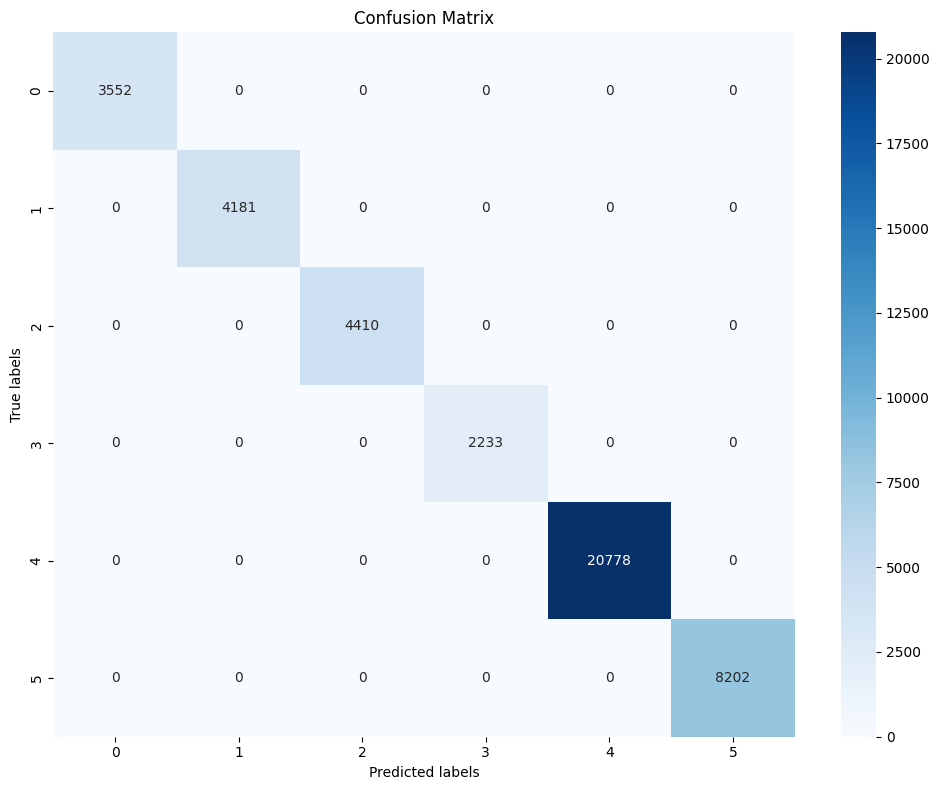

In [8]:
# Sample
subset = X_clust_scaled.sample(n=len(X_clust_scaled) // 10, random_state=42)
X_sub = subset.values


n_cluster = 6  # Number of clusters to find

# Agglomerative clustering
labels = AgglomerativeClustering(n_clusters=n_cluster).fit_predict(X_sub)

# Spectral clustering
#labels = SpectralClustering(n_clusters=n_cluster, affinity='nearest_neighbors').fit_predict(X_sub)

# HDBSCAN clustering
#labels = hdbscan.HDBSCAN(min_cluster_size=len(X_clust_scaled) // 50).fit_predict(X_sub)

# Gaussian Mixture Model clustering
#labels = GaussianMixture(n_components=n_cluster, random_state=42).fit_predict(X_sub)

# k-means clustering
#kmeans = KMeans(n_clusters=n_cluster, random_state=42)
#labels = kmeans.fit_predict(X_sub)

# Train a classifier
clf = RandomForestClassifier()
clf.fit(X_sub, labels)

# evaluate the accuracy of the Random Forest classifier
accuracy = accuracy_score(labels, clf.predict(X_sub))
print(f"Accuracy of the Random Forest classifier: {accuracy:.2f}")

# plot the confusion matrix
cm = confusion_matrix(labels, clf.predict(X_sub))
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(labels), yticklabels=np.unique(labels))
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix')
plt.tight_layout()


In [9]:
# Predict on the rest of the data
X_full = X_clust_scaled.values
predicted_labels = clf.predict(X_full)

# Add the predicted labels to the original DataFrame
merged_df['Agglomerative Cluster'] = predicted_labels

# Save the DataFrame with clusters
merged_df.to_csv('fusion_results_merged_with_clusters.csv.gzip', index=False, compression='gzip')

In [ ]:
"""# add the PC1, PC2, and PC3 to the DataFrame
merged_df['PC1'] = X_clust_scaled['PC1']
merged_df['PC2'] = X_clust_scaled['PC2']
merged_df['PC3'] = X_clust_scaled['PC3']"""

In [ ]:
"""# Vérifiez que les colonnes PC1, PC2 et PC3 existent dans merged_df
if 'PC1' in merged_df.columns and 'PC2' in merged_df.columns and 'PC3' in merged_df.columns:
    # visualize the data using the 3 components from PCA
    fig = px.scatter_3d(
        merged_df,
        x='PC1',
        y='PC2',
        z='PC3',
        color='Agglomerative Cluster',
        title='PCA of Clusters',
        labels={'Agglomerative Cluster': 'Cluster'},
        color_continuous_scale=px.colors.qualitative.Plotly
    )
    fig.update_traces(marker=dict(size=5, opacity=0.8), selector=dict(mode='markers'))
    fig.update_layout(
        scene=dict(
            xaxis_title='PC1',
            yaxis_title='PC2',
            zaxis_title='PC3'
        ),
        legend_title_text='Cluster'
    )
    fig.write_html('PCA_clusters.html')
else:
    print("Les colonnes PC1, PC2 et PC3 ne sont pas présentes dans merged_df.")"""
